# Workshop 9: Simulation
In this workshop, we will learn to devise models of real-world systems and to simulate them using the SimPy framework in Python.
This is a good first step to understand the dynamics of (simulated) environments before we dive into Reinforcement Learning in the next lecture/workshop.

## Why we use Simulation
### Goals
Using simulation, we can achieve two goals:
1. Move from a theoretical model to a more realistic model and test it numerically with different configurations.
1. Abstract from a real-world system to a simulated one and do what-if analyses with different configurations.

In both cases, we need empirical grounding of the configurations/parameters, otherwise we simulate something, but not something which can be used to guide decision-making.
Think of it this way: If would have a nice model of a football match, but we would configure the parameters with something like 2km/h run speed of the players and 5m/s gravity for the ball, this would be a fun experiment, but we would probably be closer to simulating a match on the moon than a real-world football match.

### Artifical History
When we simulate over a timespan, we can look into the activities and events, intermediate steps that were taken to arrive at a certain output, we can analyze the simulation in retrospect and potentially (not possible with all types of simulation) go back to a certain state that is interesting to us, tweak it a little and simulate again from there. With theoretical models this is not possible at all and with real-world systems we are restricted to whatever we decided to track in the first place.

### Taxonomy of Simulation Models
When approaching a problem with simulation, it's helpful to first classify the type of model we need to build. Simulation models can be categorized along a few key dimensions. 
* A primary distinction is whether a model is **deterministic** (containing no random elements) or **stochastic** (incorporating randomness to reflect real-world uncertainty). 
* We also consider if a model is **static**, representing a system at a single point in time, or **dynamic**, where the evolution of the system over time is a critical component. 
* Finally, we differentiate how time is handled: in **continuous** models, the state variables change constantly, like water filling a tank, whereas in **discrete** models, the state changes only at specific moments, triggered by events. 

## Discrete Event Simulation in SimPy
For our purposes, we will be focusing on **discrete-event simulation**, which models systems that are typically dynamic and stochastic.
The system is modeled as a sequence of events where the simulation clock jumps from one event to the next. As it ignores time where no event happens it is computationally efficient.
We can therefore differentiate four key components:
1. Entities, these are actors or agents.
1. Events, the occurrences that change the system's (its entitities') state.
1. Acitivities, these are the processes that take time in between events.
1. Resources, these are objects with capacity that be used by entities, optionally to perform activities. Resources can also trigger (e.g. on full/empty).

Let's look at a simple example of a discrete-event simulation in Python using the SimPy framework.

SimPy has a couple of important components:
* The **environment** which is where all the mentioned components reside in and which has the "clock". Usually initialized with `env = simpy.Environment()` and a start time of 0.
* The **time** that passes in the simulation to mark the passage of events and clock. To let time pass in the simulaton, use `env.timeout(<duration>)`.
* The **events** which are triggers that can happen either through waiting (`timeout` is such a special case) or through active triggers. 
* The **processes** which are the activities happen sequentially or concurrently. They can be interrupted by _yielding_ to events, i.e., waiting for them to happen. Because processes are special types of events as well, they can be _yielded_ as well (i.e., waited for completion).

There are two ways to run processes in the environment:
1. In parallel (start and forget): `env.process(<my_process>)`
1. In sequence (start and wait for completion): `yield env.run(<my_process>)`

A process is a generator, meaning that it must yield something to the environment. Often this is a timeout or a child-process.

Let's implement a simple timer:

In [4]:
import simpy
env = simpy.Environment()

WAKE_ME_UP_AFTER = 5

def timer(env, alarm_time):
    while env.now < alarm_time:
        yield env.timeout(1)
        print("tick")
    
    print('beeep beeep beep')

env.process(timer(env, WAKE_ME_UP_AFTER))
env.run()

tick
tick
tick
tick
tick
beeep beeep beep


Observe what happens when we change the timer to 10 seconds instead of 5 seconds: Nothing really in terms of compute time, because the clock in the simulation is exactly that: Simulated time, it has nothing to do with real time, and if the simulation is coded efficiently, it will run much faster than real time.

Now let's look at the environment's state, that is, it's clock:

In [7]:
env.now

5

We see that the environment is at the end state. If we would want to run it again, we would need to reset the environment, which in SimPy is equivalent to recreating the environment.

Now, let's look at one more important component in SimPy: 
**Ressources** are objects that can be consumed by processes and which can be of multiple types:
* Resource: A resource has a limited capacity and can therefore be used by a limited number of processes at the same time.
* A container models the production and consumption of a homogeneous good that can be continuous or discrete.
* A store is a generalized container that allow for the production and consumption of arbitrary Python objects.

Additionally, they can be:
* Prioritized, with a queue of waiting processes that is sorted by priority (the priority needs to be set in requesting it).
* Preemptive, where a process can interrupt another process that is using the resource without waiting on the resource.

Let's model a gas station with a limited number of pumps where cars arrive at random intervals:

In [10]:
import random

# --- Constants for Simulation Configuration ---
RANDOM_SEED = 42          # Seed for random number generator for reproducibility
NUM_PUMPS = 2             # Number of pumps at the gas station
AVG_REFUEL_TIME = 8       # Average time it takes to refuel a car, in minutes
INTERARRIVAL_TIME = 3     # Average time between car arrivals, in minutes
SIM_TIME = 60            # Total simulation time, in minutes

# A list to store the waiting times of each car to calculate statistics later
wait_times = []

# --- Process Functions ---

def car(env, name, gas_station):
    """
    Defines the process a car goes through: arriving, waiting for a pump,
    refueling, and leaving.
    """
    arrival_time = env.now
    print(f'{arrival_time:6.2f}: {name} arrives at the gas station.')

    # Use a 'with' statement to request a resource. This is a best practice
    # as it automatically handles releasing the resource. 
    with gas_station.request() as request:
        yield request  # Wait until the request for a pump is granted

        # The car has now secured a pump.
        got_pump_time = env.now
        wait = got_pump_time - arrival_time
        wait_times.append(wait) # Record the waiting time
        
        print(f'{got_pump_time:6.2f}: {name} starts refueling (waited {wait:.2f} minutes).')

        # Generate a stochastic refueling time from a triangular distribution.
        # This makes the simulation more realistic than a fixed time.
        refuel_duration = random.triangular(low=AVG_REFUEL_TIME - 3, high=AVG_REFUEL_TIME + 5, mode=AVG_REFUEL_TIME)
        
        # Yield a timeout to simulate the passage of time for the activity.
        yield env.timeout(refuel_duration)

        print(f'{env.now:6.2f}: {name} finishes refueling and leaves.')


def setup(env, num_pumps, interarrival_time):
    """
    Sets up the gas station and generates new cars arriving at random intervals.
    """
    # Create the gas station resource with a limited number of pumps. 
    gas_station = simpy.Resource(env, capacity=num_pumps)
    
    # Start the initial car process.
    env.process(car(env, 'Car 0', gas_station))
    i = 1

    # Keep generating cars until the simulation time is reached.
    while True:
        # Yield a timeout for the time until the next car arrives.
        # random.expovariate is often used to model interarrival times.
        yield env.timeout(random.expovariate(1.0 / interarrival_time))
        
        env.process(car(env, f'Car {i}', gas_station))
        i += 1


# --- Main Simulation Execution ---

print('--- Gas Station Simulation ---')
# Set the random seed to ensure the simulation is reproducible.
random.seed(RANDOM_SEED)

# Create a simpy environment. 
env = simpy.Environment()

# Start the setup process, which will in turn create the gas station and cars.
env.process(setup(env, NUM_PUMPS, INTERARRIVAL_TIME))

# Run the simulation for a set amount of time.
env.run(until=SIM_TIME)


# --- Results Analysis ---
if wait_times:
    avg_wait_time = sum(wait_times) / len(wait_times)
    print(f'\n--- Simulation Finished ---')
    print(f'Average wait time for a pump: {avg_wait_time:.2f} minutes')
    print(f'Number of cars served: {len(wait_times)}')
else:
    print('\n--- Simulation Finished ---')
    print('No cars were served in the given simulation time.')

--- Gas Station Simulation ---
  0.00: Car 0 arrives at the gas station.
  0.00: Car 0 starts refueling (waited 0.00 minutes).
  3.06: Car 1 arrives at the gas station.
  3.06: Car 1 starts refueling (waited 0.00 minutes).
  4.03: Car 2 arrives at the gas station.
  5.77: Car 0 finishes refueling and leaves.
  5.77: Car 2 starts refueling (waited 1.75 minutes).
  8.03: Car 3 arrives at the gas station.
 10.37: Car 1 finishes refueling and leaves.
 10.37: Car 3 starts refueling (waited 2.35 minutes).
 14.71: Car 4 arrives at the gas station.
 15.18: Car 2 finishes refueling and leaves.
 15.18: Car 4 starts refueling (waited 0.47 minutes).
 16.35: Car 5 arrives at the gas station.
 16.82: Car 3 finishes refueling and leaves.
 16.82: Car 5 starts refueling (waited 0.47 minutes).
 17.09: Car 6 arrives at the gas station.
 17.17: Car 7 arrives at the gas station.
 17.84: Car 8 arrives at the gas station.
 20.99: Car 9 arrives at the gas station.
 21.02: Car 4 finishes refueling and leaves.


## Agent-Based Modeling
In the example(s) above, we mostly "made" the simulation do what we wanted it to do, and one could say that the sequence of events was logical from the structure of the processes.
Another approach is called agent-based modeling (**ABM**), where we model the system as a collection of agents that each follow individual goal-driven behaviors andinteract with each other and the environment to arrive at **emergent** behaviors that are hard to infer from the single agents alone: Complex, system-level patterns arise from simple, local interactions between agents. Frameworks like SimPy are excellent for implementing ABM because each agent's behavior can be modelled as a process and we only need to define the interaction.

When we later consider _learning agents_ we will see that we can use ABM to model interfaces between the agents and the environment that are generalizable which means that we can simply swap out the behavior of one agent without having to remodel the system.

Let's consider the following example: A population of agents can be in one of three states: Healthy, Sick, and Recovered. Each agent has a certain chance of getting sick when encountering another sick agent, and after a certain amount of time they will recover. We can model this with the following agent-based model:

In [11]:
class Agent:
    """
    Represents an autonomous agent in the epidemic simulation.
    The agent's behavior (infecting others, recovering) is defined
    as methods of this class.
    """
    def __init__(self, agent_id, env, population):
        self.id = agent_id
        self.env = env
        self.population = population
        self.state = 'H'  # 'H' for Healthy

    def start_infection(self):
        """
        This method is called by another agent to infect this one.
        It starts the agent's main 'run' process. We check the state
        to ensure a susceptible agent isn't re-infected in the same time step.
        """
        if self.state == 'H':
            self.env.process(self.infection_period())

    def infection_period(self):
        """
        The main process that defines the agent's behavior once infected.
        """
        self.state = 'I'  # Become infected

        # The agent remains infectious for a period of time.
        # We use a 'for' loop to represent daily actions.
        for day in range(RECOVERY_DAYS):
            self.try_to_infect_others()
            yield self.env.timeout(1) # Wait for the next day

        self.state = 'R'  # Recover after the infectious period

    def try_to_infect_others(self):
        """
        During its infectious period, the agent tries to infect
        a number of other random agents each day.
        """
        for _ in range(CONTACTS_PER_DAY):
            # Choose a random agent from the entire population to interact with.
            other_agent = random.choice(self.population)
            
            # If the other agent is susceptible, attempt to infect them.
            if other_agent.state == 'H':
                if random.random() < INFECTION_PROBABILITY:
                    # Trigger the infection in the other agent.
                    other_agent.start_infection()

Now we need to setup the simulation environment again and initialize the population with a couple of initially infected agents.
We will also have a prober process running in parallel that extracts metrics from the population so we can plot it afterwards

In [19]:
# --- Simulation Configuration ---
RANDOM_SEED = 42
POPULATION_SIZE = 1000
INITIAL_INFECTED = 5
RECOVERY_DAYS = 14
INFECTION_PROBABILITY = 0.02
CONTACTS_PER_DAY = 8
SIM_DURATION = 200

# --- Data Collection Lists ---
h_counts, i_counts, r_counts = [], [], []

def prober(env, population):
    """
    A simple process to periodically collect data on the state of the population.
    This function remains the same as it is an external observer.
    """
    while True:
        # Count agents in each state
        counts = {'H': 0, 'I': 0, 'R': 0}
        for agent in population:
            counts[agent.state] += 1
        
        h_counts.append(counts['H'])
        i_counts.append(counts['I'])
        r_counts.append(counts['R'])
        
        # End the simulation if the epidemic has died out
        if counts['I'] == 0 and len(i_counts) > INITIAL_INFECTED:
            print(f"Epidemic ended on day {int(env.now)}.")
            return # This will stop the simulation
            
        yield env.timeout(1)

# --- Main Simulation Execution ---

print("--- ABM Epidemic Simulation ---")
random.seed(RANDOM_SEED)

# Create a simpy environment
env = simpy.Environment()

# Create the population of autonomous agents, giving each a reference
# to the environment and the population list so they can interact.
population = [Agent(i, env, None) for i in range(POPULATION_SIZE)]
# Now that all agents are created, give them the complete list
for agent in population:
    agent.population = population

# --- Kick off the simulation ---
# There is no central controller. We just "kick" the initial agents
# and let their autonomous behavior run the simulation.
for i in range(INITIAL_INFECTED):
    population[i].start_infection()

# Start the data-gathering prober process
env.process(prober(env, population))

# Run the simulation
env.run(until=SIM_DURATION)

--- ABM Epidemic Simulation ---
Epidemic ended on day 94.


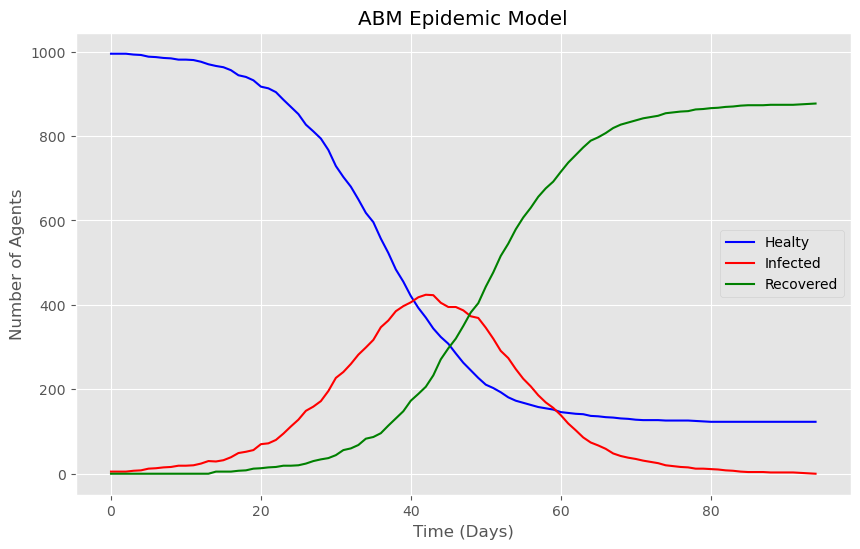

In [20]:
import matplotlib.pyplot as plt

# --- Plotting the Results ---
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 6))
days = range(len(h_counts))
ax.plot(days, h_counts, label='Healty', color='blue')
ax.plot(days, i_counts, label='Infected', color='red')
ax.plot(days, r_counts, label='Recovered', color='green')
ax.set_xlabel('Time (Days)')
ax.set_ylabel('Number of Agents')
ax.set_title('ABM Epidemic Model')
ax.legend()
plt.grid(True)
plt.show()

## Your Task: EV Charging Behavior

A city has opened a new public EV charging hub with a limited number of fast chargers. EV drivers arrive throughout the day, but their behavior can change based on how busy the hub is. Your goal is to simulate this hub to understand the impact of different driver behaviors.

1. The patient driver: 
* An agent arrives at the hub and they request a charging spot.
* No matter how long the wait time, they patiently wait in queue.
* Once a spot is free, they charge their vehicle and leave the hub when it is fully charged.

2. The impatient driver:
* An agent arrives at the hub.
* Before joining the queue they check how many cars are already waiting.
* If the number of cars waiting is below their tolerance, they join the queue.
* Otherwise, they leave the hub immediately.

Run simulations with both types of drivers (or even a mixture) and compare the results:
* How does the average waiting time for the drivers who do charge change between the two driver types?
* How does the hub's overall charger utilization change?

In [38]:
SIMULATED_TIME = 24 * 60 # one full day
CHARGING_SPOTS = 3
AVG_INTERARRIVAL = 20 # minutes
CHARGING_SPEED = 22 # kW
BATTERY_CAPACITY = 50 # kWh
MIN_SOC = 0.2 # Minimum State of Charge drivers will arrive with
MAX_SOC = 0.8 # Maximum State of Charge drivers will arrive with
QUEUE_TOLERANCE = 1 # how many cars in queue are okay with the impatient driver

In [22]:
# your code here...

Let's first define the two agents and their behavior:

In [30]:
# --- Agent Class Definitions ---

class PatientDriver:
    """
    An agent who will always wait for a charger, no matter how long the queue.
    """
    def __init__(self, agent_id, env, hub, rng):
        self.id = agent_id
        self.env = env
        self.hub = hub
        self.rng = rng
        
        initial_soc = self.rng.uniform(MIN_SOC, MAX_SOC)
        energy_needed_kWh = (1.0 - initial_soc) * BATTERY_CAPACITY
        self.required_charge_time = (energy_needed_kWh / CHARGING_SPEED) * 60

    def run(self):
        """The main process. This agent is patient and always joins the queue."""
        arrival_time = self.env.now
        print(f"{arrival_time:7.2f}: {self.id} arrives (needs {self.required_charge_time:.2f} mins).")
        
        with self.hub.request() as request:
            yield request # Waits indefinitely for a spot

            got_spot_time = self.env.now
            wait_time = got_spot_time - arrival_time
            results["wait_times"].append(wait_time)
            
            print(f"{got_spot_time:7.2f}: {self.id} starts charging (waited {wait_time:.2f} mins).")

            yield self.env.timeout(self.required_charge_time)

            print(f"{self.env.now:7.2f}: {self.id} finishes charging and leaves.")
            results["cars_charged_count"] += 1
            results["charge_times_completed"].append(self.required_charge_time)

class ImpatientDriver:
    """
    An agent who checks the queue length and leaves if it's too long.
    """
    def __init__(self, agent_id, env, hub, rng, tolerance):
        self.id = agent_id
        self.env = env
        self.hub = hub
        self.rng = rng
        self.tolerance = tolerance
        
        initial_soc = self.rng.uniform(MIN_SOC, MAX_SOC)
        energy_needed_kWh = (1.0 - initial_soc) * BATTERY_CAPACITY
        self.required_charge_time = (energy_needed_kWh / CHARGING_SPEED) * 60

    def run(self):
        """The main process. This agent decides whether to join the queue."""
        arrival_time = self.env.now
        print(f"{arrival_time:7.2f}: {self.id} arrives (needs {self.required_charge_time:.2f} mins).")

        if len(self.hub.queue) > self.tolerance:
            print(f"{self.env.now:7.2f}: {self.id} sees a queue of {len(self.hub.queue)} and BALKS.")
            results["cars_balked_count"] += 1
            return

        with self.hub.request() as request:
            yield request

            got_spot_time = self.env.now
            wait_time = got_spot_time - arrival_time
            results["wait_times"].append(wait_time)
            
            print(f"{got_spot_time:7.2f}: {self.id} starts charging (waited {wait_time:.2f} mins).")

            yield self.env.timeout(self.required_charge_time)

            print(f"{self.env.now:7.2f}: {self.id} finishes charging and leaves.")
            results["cars_charged_count"] += 1
            results["charge_times_completed"].append(self.required_charge_time)

Now let's run a simulation with patient drivers, and one with impatient drivers and compare the metrics:

In [39]:
import numpy as np

# Calculated Values
ARRIVAL_RATE = 1.0 / AVG_INTERARRIVAL

# --- Generic Setup Function ---

def setup(env, hub, arrival_rate, rng, driver_class, **kwargs):
    """Generates new drivers of a specified class."""
    agent_count = 0
    while True:
        yield env.timeout(rng.exponential(scale=1.0 / arrival_rate))
        agent_count += 1
        driver = driver_class(f"Driver {agent_count}", env, hub, rng, **kwargs)
        env.process(driver.run())

In [40]:
DRIVER_TYPE = "patient"

# --- Main Simulation Execution ---

# Data Collection
results = {
    "wait_times": [],
    "charge_times_completed": [],
    "cars_charged_count": 0,
    "cars_balked_count": 0,
}

print(f"--- EV Charging Hub Simulation ({DRIVER_TYPE.title()} Driver Model) ---")
rng = np.random.default_rng(RANDOM_SEED)
env = simpy.Environment()
charging_hub = simpy.Resource(env, capacity=CHARGING_SPOTS)

# Use the DRIVER_TYPE variable to select the class and its specific arguments
if DRIVER_TYPE == "patient":
    driver_class_to_use = PatientDriver
    driver_kwargs = {}
elif DRIVER_TYPE == "impatient":
    driver_class_to_use = ImpatientDriver
    driver_kwargs = {"tolerance": QUEUE_TOLERANCE}
else:
    raise ValueError(f"Invalid DRIVER_TYPE: {DRIVER_TYPE}")

env.process(setup(env, charging_hub, ARRIVAL_RATE, rng, driver_class_to_use, **driver_kwargs))
env.run(until=SIM_DURATION)

print("\n--- Simulation Finished ---")

# Calculate average wait time for cars that actually charged and waited
if results["wait_times"]:
    avg_wait = sum(results["wait_times"]) / len(results["wait_times"])
    print(f"Average waiting time for charged cars: {avg_wait:.2f} minutes")
else:
    # This can happen if cars arrive but the simulation ends before they finish charging
    print("No cars completed a full wait-and-charge cycle.")

print(f"Total cars successfully charged: {results['cars_charged_count']}")

# Only show balking stats if that model was run
if DRIVER_TYPE == "impatient":
    print(f"Total cars that balked (left): {results['cars_balked_count']}")

# Total busy time is the sum of the time the chargers were actually running.
total_charge_time_provided = sum(results["charge_times_completed"])

# Total time the chargers could have possibly been running.
total_time_available = SIM_DURATION * CHARGING_SPOTS

# The ratio is the utilization.
utilization = total_charge_time_provided / total_time_available
print(f"Hub utilization: {utilization:.2%}")

--- EV Charging Hub Simulation (Patient Driver Model) ---
  48.08: Driver 1 arrives (needs 73.18 mins).
  48.08: Driver 1 starts charging (waited 0.00 mins).
  95.78: Driver 2 arrives (needs 52.03 mins).
  95.78: Driver 2 starts charging (waited 0.00 mins).
  97.51: Driver 3 arrives (needs 29.27 mins).
  97.51: Driver 3 starts charging (waited 0.00 mins).
 121.27: Driver 1 finishes charging and leaves.
 125.71: Driver 4 arrives (needs 44.78 mins).
 125.71: Driver 4 starts charging (waited 0.00 mins).
 126.78: Driver 3 finishes charging and leaves.
 127.29: Driver 5 arrives (needs 72.24 mins).
 127.29: Driver 5 starts charging (waited 0.00 mins).
 128.70: Driver 6 arrives (needs 33.26 mins).
 147.81: Driver 2 finishes charging and leaves.
 147.81: Driver 6 starts charging (waited 19.11 mins).
 163.33: Driver 7 arrives (needs 41.77 mins).
 170.48: Driver 4 finishes charging and leaves.
 170.48: Driver 7 starts charging (waited 7.16 mins).
 181.08: Driver 6 finishes charging and leaves.
 

In [41]:
DRIVER_TYPE = "impatient"

# --- Main Simulation Execution ---

# Data Collection
results = {
    "wait_times": [],
    "charge_times_completed": [],
    "cars_charged_count": 0,
    "cars_balked_count": 0,
}

print(f"--- EV Charging Hub Simulation ({DRIVER_TYPE.title()} Driver Model) ---")
rng = np.random.default_rng(RANDOM_SEED)
env = simpy.Environment()
charging_hub = simpy.Resource(env, capacity=CHARGING_SPOTS)

# Use the DRIVER_TYPE variable to select the class and its specific arguments
if DRIVER_TYPE == "patient":
    driver_class_to_use = PatientDriver
    driver_kwargs = {}
elif DRIVER_TYPE == "impatient":
    driver_class_to_use = ImpatientDriver
    driver_kwargs = {"tolerance": QUEUE_TOLERANCE}
else:
    raise ValueError(f"Invalid DRIVER_TYPE: {DRIVER_TYPE}")

env.process(setup(env, charging_hub, ARRIVAL_RATE, rng, driver_class_to_use, **driver_kwargs))
env.run(until=SIM_DURATION)

# --- Results Analysis ---
print("\n--- Simulation Finished ---")
if results["wait_times"]:
    avg_wait = sum(results["wait_times"]) / len(results["wait_times"])
    print(f"Average waiting time for charged cars: {avg_wait:.2f} minutes")
else:
    print("No cars were charged, so no average waiting time.")

print(f"Total cars successfully charged: {results['cars_charged_count']}")
if "tolerance" in driver_kwargs:
    print(f"Total cars that balked (left): {results['cars_balked_count']}")

total_charge_time_provided = sum(results["charge_times_completed"])
total_time_available = SIM_DURATION * CHARGING_SPOTS
utilization = total_charge_time_provided / total_time_available
print(f"Hub utilization: {utilization:.2%}")

--- EV Charging Hub Simulation (Impatient Driver Model) ---
  48.08: Driver 1 arrives (needs 73.18 mins).
  48.08: Driver 1 starts charging (waited 0.00 mins).
  95.78: Driver 2 arrives (needs 52.03 mins).
  95.78: Driver 2 starts charging (waited 0.00 mins).
  97.51: Driver 3 arrives (needs 29.27 mins).
  97.51: Driver 3 starts charging (waited 0.00 mins).
 121.27: Driver 1 finishes charging and leaves.
 125.71: Driver 4 arrives (needs 44.78 mins).
 125.71: Driver 4 starts charging (waited 0.00 mins).
 126.78: Driver 3 finishes charging and leaves.
 127.29: Driver 5 arrives (needs 72.24 mins).
 127.29: Driver 5 starts charging (waited 0.00 mins).
 128.70: Driver 6 arrives (needs 33.26 mins).
 147.81: Driver 2 finishes charging and leaves.
 147.81: Driver 6 starts charging (waited 19.11 mins).
 163.33: Driver 7 arrives (needs 41.77 mins).
 170.48: Driver 4 finishes charging and leaves.
 170.48: Driver 7 starts charging (waited 7.16 mins).
 181.08: Driver 6 finishes charging and leaves.